In [1]:
%matplotlib inline
import os, pickle, warnings, numpy as np, torch
import torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import matplotlib.pyplot as plt
from KF import DiscreteKalmanFilter
warnings.filterwarnings("ignore")
torch.manual_seed(0); np.random.seed(0)

# Semana 2 — Implementación del Controlador Neuronal

En la sesión anterior identificamos, por edificio, un modelo lineal en espacio de estados
($A,B,C,D$) y los ruidos $Q,R$, y los guardamos junto con los parámetros de los
`StandardScaler` en `results/estimacion_planta_{id}.pkl`. Sobre ese modelo construimos ahora el
**controlador neuronal**: una red que aprende, en línea, los voltajes que llevan las 6
temperaturas de cada edificio a su referencia.

La arquitectura es un controlador por edificio que se comunica por OPC UA con la planta
(la próxima semana sus pesos se combinarán por MQTT en el control federado). Este notebook
desarrolla la **Parte 1 de M2_DD** explicando, a la par del código, los fundamentos que la sustentan.

## 1. La red neuronal como controlador

Una red *feed-forward* (MLP) es una composición de capas $a^{(l)}=\sigma\!\left(W^{(l)}a^{(l-1)}+b^{(l)}\right)$.
Por el **teorema de aproximación universal**, con suficientes neuronas puede aproximar cualquier
función continua: es una *vasija* a la que le damos forma eligiendo la **función de costo**. La
misma arquitectura sirve para regresión, clasificación o —como aquí— control; lo único que
define la tarea es la pérdida.

La capa de salida usa **tangente hiperbólica**, que satura en $[-1,1]$: justo el rango de los
voltajes de los aires acondicionados (M2_DD 1.1).

In [2]:
class ControladorNeuronal(nn.Module):
    def __init__(self, input_size, output_size=6, hidden_size=128, dropout=0.3):
        super().__init__()
        self.l_in  = nn.Linear(input_size, hidden_size)
        self.l_h1  = nn.Linear(hidden_size, hidden_size)
        self.l_h2  = nn.Linear(hidden_size, hidden_size)
        self.l_h3  = nn.Linear(hidden_size, hidden_size // 2)
        self.l_out = nn.Linear(hidden_size // 2, output_size)
        self.drop  = nn.Dropout(dropout)   # apaga neuronas: regulariza y generaliza mejor

    def forward(self, x):
        x = self.l_in(x)
        x = self.drop(F.relu(self.l_h1(x)))
        x = self.drop(F.relu(self.l_h2(x)))
        x = self.drop(F.relu(self.l_h3(x)))
        return torch.tanh(self.l_out(x))    # voltajes en [-1, 1]

_demo = ControladorNeuronal(6 + 7 + 6)      # dimensiones de ejemplo (e + x + u)
print(_demo)
print("Parámetros entrenables:", sum(p.numel() for p in _demo.parameters()))

ControladorNeuronal(
  (l_in): Linear(in_features=19, out_features=128, bias=True)
  (l_h1): Linear(in_features=128, out_features=128, bias=True)
  (l_h2): Linear(in_features=128, out_features=128, bias=True)
  (l_h3): Linear(in_features=128, out_features=64, bias=True)
  (l_out): Linear(in_features=64, out_features=6, bias=True)
  (drop): Dropout(p=0.3, inplace=False)
)
Parámetros entrenables: 44230


### Variables de entrada del controlador

Siguiendo el esquema tipo MPC de la cápsula, la red recibe en cada paso $[\,e_k,\;x_k,\;u_{k-1}\,]$
y entrega $u_k$ (6 voltajes):

- $e_k = r - y_k$: el **error** respecto a la referencia — indica cuán lejos está y en qué
  dirección corregir.
- $x_k$: el **estado** estimado por el filtro de Kalman — resume la dinámica interna (la "memoria"
  térmica) que una sola medición no muestra.
- $u_{k-1}$: el **voltaje anterior** — permite penalizar cambios bruscos y dar continuidad.

Por eso `input_size = ny + nx + nv` $=6+7+6$, y la salida son los $nv=6$ voltajes.

## 2. El modelo identificado como bloque diferenciable

Las redes se entrenan por **descenso de gradiente**: se mide el error con una pérdida $L$ y se
mueven los pesos en contra de $\partial L/\partial W$. Esas derivadas se obtienen con
**backpropagation** (regla de la cadena hacia atrás), lo que exige que *todo el camino desde los
pesos hasta la pérdida sea diferenciable*.

Nuestro controlador no se entrena contra la planta real sino contra el **modelo**: la red propone
$u_k$, el modelo predice $y_{k+1}$ y la pérdida la compara con la referencia. Para que el gradiente
fluya desde $L$ a través del modelo hasta los pesos, las matrices $A,B,C,D$ deben ser **tensores de
PyTorch** (`torch.from_numpy`) y el *rollout* hacerse con operaciones torch (M2_DD 1.2). Si se
calculara $y$ con NumPy, el grafo se corta y la red nunca aprendería a seguir la referencia.

### Cargamos la estimación (matrices + scalers)

Leemos el archivo generado por `identificador_modelo.py` e imprimimos su contenido para verificar
dimensiones y estabilidad. *(Si el `.pkl` aún no existe en este entorno, se genera un modelo de
demostración estable —rotulado `[DEMO]`— para poder correr el notebook offline; al ejecutar la
identificación real se reemplaza por el modelo del edificio.)*

In [3]:
ruta = "results/estimacion_planta_2.pkl"
if os.path.exists(ruta):
    est = pickle.load(open(ruta, "rb"))
    print("Modelo identificado cargado desde:", ruta)
else:
    print("[DEMO] No se encontró", ruta, "-> usando un modelo de demostración estable.")
    nx, nu, ny = 7, 7, 6
    A = np.diag([0.90] * nx) + 0.02 * np.random.standard_normal((nx, nx))
    A *= 0.95 / np.abs(np.linalg.eigvals(A)).max()        # re-escalar a |lambda| < 1
    B = np.zeros((nx, nu))
    for k in range(6): B[k, k] = 0.30                     # cada voltaje calienta su pieza
    B[:6, 6], B[6, 6] = 0.05, 0.90                        # Tout como perturbación
    C = np.zeros((ny, nx)); C[:6, :6] = np.eye(6)         # las 6 primeras coords son las temperaturas
    D = np.zeros((ny, nu))
    est = {"A": A, "B": B, "C": C, "D": D, "Q": 0.01 * np.eye(nx), "R": 0.01 * np.eye(ny),
           "u_mean": np.r_[np.zeros(6), 10.0], "u_std": np.r_[0.5 * np.ones(6), 3.0],
           "y_mean": 21.0 * np.ones(6), "y_std": 2.0 * np.ones(6),
           "u_cols": [f"v{i+1}" for i in range(6)] + ["Tout"],
           "y_cols": [f"T_room{i+1}" for i in range(6)]}

A, B, C, D, Q, R = (est[k] for k in ["A", "B", "C", "D", "Q", "R"])
u_mean, u_std, y_mean, y_std = est["u_mean"], est["u_std"], est["y_mean"], est["y_std"]
nx, ny, nu = A.shape[0], C.shape[0], B.shape[1]; nv = nu - 1

print("\nContenido del archivo de estimación:")
for k, v in est.items():
    print(f"  {k:8s}: {np.shape(v) if hasattr(v, '__len__') else v}")
print(f"\nDimensiones -> estado nx={nx}, entradas modelo nu={nu} ([{nv} voltajes + Tout]), salidas ny={ny}")
print("Orden de entradas:", est["u_cols"])
lam = np.abs(np.linalg.eigvals(A)).max()
print(f"Polo de mayor magnitud |lambda|_max = {lam:.4f} ->", "estable" if lam < 1 else "INESTABLE")

dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
t = lambda M: torch.from_numpy(np.asarray(M, dtype=float)).float().to(dev)
At, Bt, Ct, Dt, umean_t, ustd_t = t(A), t(B), t(C), t(D), t(u_mean), t(u_std)
print("\nMatrices del modelo convertidas a tensores torch (entran al grafo para el backprop).")

[DEMO] No se encontró results/estimacion_planta_2.pkl -> usando un modelo de demostración estable.

Contenido del archivo de estimación:
  A       : (7, 7)
  B       : (7, 7)
  C       : (6, 7)
  D       : (6, 7)
  Q       : (7, 7)
  R       : (6, 6)
  u_mean  : (7,)
  u_std   : (7,)
  y_mean  : (6,)
  y_std   : (6,)
  u_cols  : (7,)
  y_cols  : (6,)

Dimensiones -> estado nx=7, entradas modelo nu=7 ([6 voltajes + Tout]), salidas ny=6
Orden de entradas: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'Tout']
Polo de mayor magnitud |lambda|_max = 0.9500 -> estable

Matrices del modelo convertidas a tensores torch (entran al grafo para el backprop).


### Normalización consistente

El modelo se identificó con datos **normalizados**, así que el controlador opera en ese mismo
espacio: normaliza lo que entra al modelo y desnormaliza lo que sale, con la **misma** media y
desviación del entrenamiento, $z_{norm}=(z-\mu)/\sigma$. El objeto `StandardScaler` no es portable
al reComputer, por eso se guardan solo `mean_` y `scale_` como arreglos (M2_DD 1.4).

El modelo tiene 7 canales $[v_1..v_6,\,T_{out}]$: los **voltajes** se aplican crudos a la planta
($[-1,1]$) pero se normalizan antes de entrar al modelo, y $T_{out}$ es una **perturbación medida**
que se lee de la planta y se mantiene fija a lo largo del horizonte.

In [4]:
r_setpoint = 22.0
r_norm = (np.full(ny, r_setpoint) - y_mean) / y_std
print("Referencia 22 C  ->  normalizada:", np.round(r_norm, 3))

v_ejemplo = np.array([0.2, -0.1, 0.0, 0.5, -0.3, 0.1])     # salida cruda de la red
tout = 10.0
u7 = np.concatenate([v_ejemplo, [tout]])
print("Entrada al modelo [v1..v6, Tout]:", np.round(u7, 2))
print("  normalizada con su scaler     :", np.round((u7 - u_mean) / u_std, 2))

rn = t(r_norm); tout_t = t(np.array([tout]))               # se reutilizan en el lazo

Referencia 22 C  ->  normalizada: [0.5 0.5 0.5 0.5 0.5 0.5]
Entrada al modelo [v1..v6, Tout]: [ 0.2 -0.1  0.   0.5 -0.3  0.1 10. ]
  normalizada con su scaler     : [ 0.4 -0.2  0.   1.  -0.6  0.2  0. ]


## 3. Control predictivo y función de costo

El **MPC** usa un modelo para predecir el comportamiento a un horizonte $H$, optimiza la secuencia
de entradas que lleva el sistema a la referencia y aplica **solo la primera**. Aquí, en vez de
re-optimizar cada paso, una red aprende esa política. La pérdida (tipo MPC) tiene tres términos:

$$L=\sum_{k=0}^{H-1}\underbrace{W_y\,(y_{k+1}-r)^2}_{\text{seguimiento}}+\underbrace{W_u\,(u_{k+1}-u_k)^2}_{\text{suavidad}}+\underbrace{W_f\,(y_H-r)^2}_{\text{costo terminal}}$$

- **Seguimiento:** empuja las temperaturas a la referencia en todo el horizonte.
- **Suavidad / esfuerzo:** penaliza cambios bruscos del voltaje (señal suave, menos desgaste);
  variantes alternativas penalizan la magnitud $u^2$ o agregan restricciones.
- **Costo terminal:** peso extra al final del horizonte para forzar la llegada a la referencia.

Los pesos $W_y,W_u,W_f$ se eligen según la prioridad (seguimiento vs. suavidad).

### El lazo interno: *rollout* diferenciable

Partiendo del estado $x_0$ (del Kalman), propagamos el modelo $H$ pasos: la red entrega $u_k$, el
modelo da $x_{k+1}=Ax_k+Bu_k$ e $y_{k+1}=Cx_{k+1}+Du_k$, recalculamos el error y repetimos.
Acumulamos la pérdida del horizonte y hacemos un único `backward`. Lo construimos explícito primero:

In [5]:
H, (Wy, Wu, Wf) = 14, (1.0, 0.01, 5.0)
model = ControladorNeuronal(ny + nx + nv, nv, 128).to(dev)
opt = optim.Adam(model.parameters(), lr=1e-3)

x  = torch.zeros(nx, device=dev)     # estado inicial (lo da el Kalman en el sistema real)
yc = torch.zeros(ny, device=dev)     # y normalizada actual (medición)
v  = torch.zeros(nv, device=dev)     # u_{k-1}: voltaje anterior

opt.zero_grad(); J = 0.0
for k in range(H):
    entrada = torch.cat([rn - yc, x, v])              # [e_k, x_k, u_{k-1}]
    vn = model(entrada)                               # u_k
    u  = (torch.cat([vn, tout_t]) - umean_t) / ustd_t # a entrada del modelo (normalizada)
    x  = At @ x + Bt @ u                              # x_{k+1} = A x_k + B u_k
    yc = Ct @ x + Dt @ u                              # y_{k+1} = C x_{k+1} + D u_k
    J  = J + Wy * ((yc - rn) ** 2).sum() + Wu * ((vn - v) ** 2).sum()
    if k == 0:
        print(f"Paso 0 -> entrada {tuple(entrada.shape)}, voltajes {tuple(vn.shape)}, y_pred {tuple(yc.shape)}")
    v = vn
J = J + Wf * ((yc - rn) ** 2).sum()                  # costo terminal
J.backward()
print(f"\nLoss del horizonte: {J.item():.4f}")
print("Gradiente en la 1a capa:", model.l_in.weight.grad is not None,
      "| norma:", round(float(model.l_in.weight.grad.norm()), 4))
print("El gradiente atraviesa A,B,C,D: la red aprende A TRAVES del modelo.")

Paso 0 -> entrada (19,), voltajes (6,), y_pred (6,)



Loss del horizonte: 48.8876
Gradiente en la 1a capa: True | norma: 11.4947
El gradiente atraviesa A,B,C,D: la red aprende A TRAVES del modelo.


El mismo lazo interno, empaquetado en una función. Se aísla a propósito (M2_DD 1.4): la próxima
semana, el control federado lo reutiliza tal cual.

In [6]:
def entrenar(model, opt, At, Bt, Ct, Dt, x, yc, v, rn, tout, umean, ustd, H, Wy, Wu, Wf):
    opt.zero_grad()
    J, v0 = 0.0, None
    for k in range(H):
        vn = model(torch.cat([rn - yc, x, v]))
        u  = (torch.cat([vn, tout]) - umean) / ustd
        x  = At @ x + Bt @ u
        yc = Ct @ x + Dt @ u
        J  = J + Wy * ((yc - rn) ** 2).sum() + Wu * ((vn - v) ** 2).sum()
        if k == 0: v0 = vn
        v = vn
    J = J + Wf * ((yc - rn) ** 2).sum()
    J.backward(); opt.step()
    return J.item(), v0.detach().cpu().numpy()

## 4. El filtro de Kalman: fijar el estado inicial

El estado $x$ del modelo es abstracto: no se mide. Antes de cada *rollout*, el filtro de Kalman
(`KF.py`) estima $x_0$: hace `predict` con el último voltaje aplicado y `update` con la medición
actual de temperaturas (ambas **normalizadas**, y en el orden `step(u, y)`). Se usa **una vez por
paso real**; dentro del horizonte el estado lo propaga el propio modelo.

### Verificación del lazo interno

Entrenamos el lazo interno muchas veces sobre un estado fijo: la pérdida debe bajar, confirmando
que el backprop atraviesa el modelo y la red aprende a llevar las salidas a la referencia.

Loss: 19.707  ->  0.166  (baja entrenando solo contra el modelo)


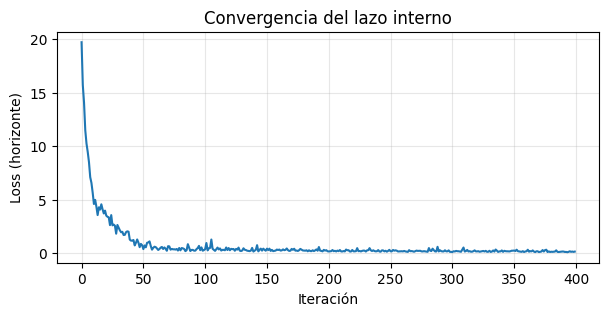

In [7]:
model = ControladorNeuronal(ny + nx + nv, nv, 128).to(dev)
opt = optim.Adam(model.parameters(), lr=1e-3)
x0 = torch.zeros(nx, device=dev); y0 = torch.zeros(ny, device=dev); v0 = torch.zeros(nv, device=dev)

curva = [entrenar(model, opt, At, Bt, Ct, Dt, x0, y0, v0, rn, tout_t, umean_t, ustd_t, H, Wy, Wu, Wf)[0]
         for _ in range(400)]
print(f"Loss: {curva[0]:.3f}  ->  {curva[-1]:.3f}  (baja entrenando solo contra el modelo)")
plt.figure(figsize=(7, 3))
plt.plot(curva); plt.xlabel("Iteración"); plt.ylabel("Loss (horizonte)")
plt.title("Convergencia del lazo interno"); plt.grid(alpha=0.3); plt.show()

### Métricas de desempeño

Para cuantificar el seguimiento usamos una métrica integral del error; M2_DD pide al menos una:

$$\text{IAE}=\sum_k |r-y_k|,\qquad \text{ISE}=\sum_k (r-y_k)^2,\qquad \text{ITAE}=\sum_k k\,|r-y_k|$$

Acumulamos **IAE** y la guardamos junto con la curva de pérdida.

### Verificación en simulación (lazo cerrado)

Antes de desplegar en el reComputer cerramos el lazo usando el propio modelo como planta simulada.
Reproduce el flujo real (medir → estimar estado → entrenar → aplicar voltaje) y entrega los
gráficos que pide el informe: evolución de la pérdida y seguimiento de la referencia.

IAE acumulado (6 piezas, 600 pasos): 248.2


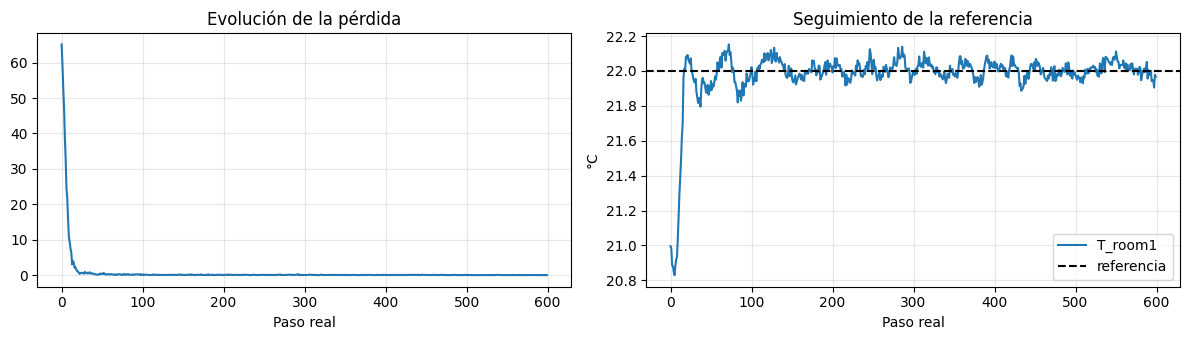

In [8]:
model = ControladorNeuronal(ny + nx + nv, nv, 128).to(dev)
opt = optim.Adam(model.parameters(), lr=1e-3)
kalman = DiscreteKalmanFilter.create(A=A, B=B, C=C, Q=Q, R=R, P_init=np.eye(nx), D=D, x_init=np.zeros((nx, 1)))

x_planta = np.zeros((nx, 1))                 # estado oculto de la planta simulada
v_prev, sala = np.zeros(nv), 0
losses, temps, iae, N = [], [], 0.0, 600
for n in range(N):
    y = (C @ x_planta + D @ np.r_[v_prev, [tout]].reshape(nu, 1)).ravel() * y_std + y_mean
    y += 0.02 * np.random.standard_normal(ny)                          # ruido de medición
    y_n = (y - y_mean) / y_std
    u_prev = (np.r_[v_prev, [tout]] - u_mean) / u_std
    kalman.step(u_prev.reshape(nu, 1), y_n.reshape(ny, 1))             # semilla x0
    loss, v0 = entrenar(model, opt, At, Bt, Ct, Dt, t(kalman.x.flatten()), t(y_n), t(v_prev),
                        rn, tout_t, umean_t, ustd_t, H, Wy, Wu, Wf)
    x_planta = A @ x_planta + B @ ((np.r_[v0, [tout]] - u_mean) / u_std).reshape(nu, 1)  # avanzar planta
    v_prev = v0
    iae += float(np.abs(r_setpoint - y).sum())
    losses.append(loss); temps.append(float(y[sala]))

print(f"IAE acumulado (6 piezas, {N} pasos): {iae:.1f}")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(losses); ax[0].set_title("Evolución de la pérdida"); ax[0].set_xlabel("Paso real"); ax[0].grid(alpha=0.3)
ax[1].plot(temps, label=f"T_room{sala+1}"); ax[1].axhline(r_setpoint, ls="--", c="k", label="referencia")
ax[1].set_title("Seguimiento de la referencia"); ax[1].set_xlabel("Paso real"); ax[1].set_ylabel("°C")
ax[1].legend(); ax[1].grid(alpha=0.3); plt.tight_layout(); plt.show()

La pérdida cae y la temperatura de la pieza converge a la referencia: el controlador aprende,
solo interactuando con el modelo, los voltajes correctos. Con el modelo real del edificio el
comportamiento es análogo; el error de modelo, si lo hay, lo mitiga el filtro de Kalman.

## 5. Lazo de control en línea (reComputer)

El lazo externo corre en el reComputer contra la planta real: en cada paso lee temperaturas y
$T_{out}$, estima el estado, entrena el controlador y envía los 6 voltajes. Guarda la pérdida, la
temperatura y el IAE en `results/control_planta_{id}.pkl` para el análisis posterior, e imprime en
consola loss + temperatura + referencia. Se ejecuta por edificio (2, 3, 4) cambiando `plant_id`.

```
Cada paso real (reComputer):
    y, Tout  <- leer planta (OPC UA)
    x0       <- Kalman.step(u_prev_norm, y_norm)          # fijar el estado
    para k = 0..H-1   (solo el modelo):                   # lazo interno
        u_k              <- red([ r - y_k , x_k , u_{k-1} ])
        x_{k+1}, y_{k+1} <- modelo(x_k, u_k)
        L += Wy (y_{k+1}-r)^2 + Wu (u_k-u_{k-1})^2
    L += Wf (y_H - r)^2
    backward(L); optimizer.step()                         # aprender
    aplicar u_0 a la planta ; u_prev <- u_0
    registrar loss, temperatura, IAE
```

In [9]:
def control(plant_id=2, r_setpoint=22.0, sala=0, H=14, hidden=128, lr=1e-3,
            Wy=1.0, Wu=0.01, Wf=5.0, every=10):
    from buildingClient import MyClient
    est = pickle.load(open(f"results/estimacion_planta_{plant_id}.pkl", "rb"))
    A, B, C, D, Q, R = (est[k] for k in ["A", "B", "C", "D", "Q", "R"])
    u_mean, u_std, y_mean, y_std = est["u_mean"], est["u_std"], est["y_mean"], est["y_std"]
    nx, ny, nu = A.shape[0], C.shape[0], B.shape[1]; nv = nu - 1
    dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    t = lambda M: torch.from_numpy(np.asarray(M, dtype=float)).float().to(dev)
    At, Bt, Ct, Dt, umean_t, ustd_t = t(A), t(B), t(C), t(D), t(u_mean), t(u_std)
    rn = (torch.full((ny,), r_setpoint, device=dev) - t(y_mean)) / t(y_std)
    model = ControladorNeuronal(ny + nx + nv, nv, hidden).to(dev)
    opt = optim.Adam(model.parameters(), lr=lr)
    kalman = DiscreteKalmanFilter.create(A=A, B=B, C=C, Q=Q, R=R, P_init=np.eye(nx), D=D, x_init=np.zeros((nx, 1)))
    v_prev, losses, temps, iae, n = np.zeros(nv), [], [], 0.0, 0
    client = MyClient("opc.tcp://192.168.1.142:4840/freeopcua/server/"); client.connect()
    step = int(client.sim_step.get_value())
    try:
        while True:
            step = client.wait_for_next_step(step)
            y = np.array([client.T_rooms[f'T_room{i+1}'].get_value() for i in range(ny)])
            tout = client.T_outdoor.get_value()
            y_n = (y - y_mean) / y_std
            u_prev = (np.concatenate([v_prev, [tout]]) - u_mean) / u_std
            kalman.step(u_prev.reshape(nu, 1), y_n.reshape(ny, 1))
            loss, v0 = entrenar(model, opt, At, Bt, Ct, Dt, t(kalman.x.flatten()), t(y_n), t(v_prev),
                                rn, t(np.array([tout])), umean_t, ustd_t, H, Wy, Wu, Wf)
            for i in range(nv): client.voltages[f'Volt_room{i+1}'].set_value(float(v0[i]))
            v_prev = v0
            iae += float(np.abs(r_setpoint - y).sum())
            losses.append(loss); temps.append(float(y[sala]))
            if n % every == 0:
                print(f"[{step}] T{sala+1}={y[sala]:.2f}C ref={r_setpoint:.1f} loss={loss:.4f} IAE={iae:.1f}",
                      end="\r", flush=True)
            n += 1
    finally:
        client.disconnect()
        os.makedirs("results", exist_ok=True)
        pickle.dump({"loss": np.array(losses), "temp": np.array(temps), "ref": r_setpoint,
                     "sala": sala, "iae": iae}, open(f"results/control_planta_{plant_id}.pkl", "wb"))

print("control() definido. En el reComputer: control(plant_id=2) por cada edificio (2, 3, 4).")

control() definido. En el reComputer: control(plant_id=2) por cada edificio (2, 3, 4).


## Cierre — cómo se cumple M2_DD (Parte 1)

| Requisito | Dónde se resuelve |
|---|---|
| 1.1 Clase de la red; salida = voltajes; justificar entradas | `ControladorNeuronal` (§1) + justificación de $[e_k,x_k,u_{k-1}]$ |
| 1.2 Backprop a través del modelo N4SID | Modelo como tensores torch + *rollout* diferenciable (§2) |
| 1.3 Costo tipo MPC con horizonte; justificar términos | Pérdida seguimiento + suavidad + terminal (§3) |
| 1.4 Lógica de entrenamiento en una función; normalización; usar KF.py | `entrenar` + scalers cargados + Kalman (§3–4) |
| 1.5 Validar; consola loss+temp+ref; guardar pérdidas + métrica | Lazo `control()` + IAE en `.pkl` (§5) |
| Informe: arquitectura, pseudocódigo, pérdida, gráficos | Todo este notebook |

El **bonus** (capa de seguridad por *Control Barrier Functions*) queda fuera de este alcance.